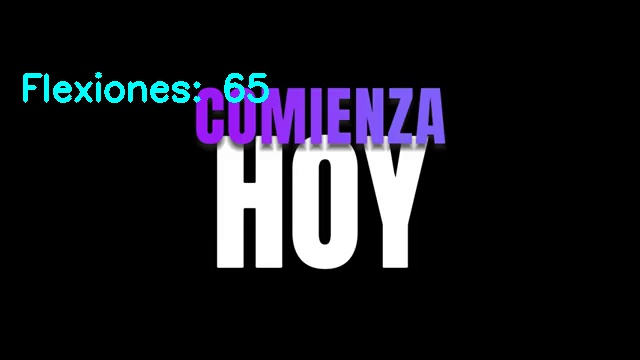


Análisis completado. Total de flexiones: 65


In [12]:
import cv2
from ultralytics import YOLO
import math
import IPython.display as ipd
from IPython.display import display, Image as IPImage

# ── Función para calcular ángulo ──────────────────────────────────────────────
def calcular_angulo(A, B, C):
    radianes = math.atan2(C[1] - B[1], C[0] - B[0]) - \
               math.atan2(A[1] - B[1], A[0] - B[0])
    angulo = abs(radianes * 180.0 / math.pi)
    if angulo > 180.0:
        angulo = 360 - angulo
    return angulo

# ── Configuración ─────────────────────────────────────────────────────────────
model = YOLO("yolo11n-pose.pt")
cap   = cv2.VideoCapture("video.mp4")

contador   = 0
estado     = None
estado_ant = None

print("Iniciando análisis...")

# ── Bucle principal ───────────────────────────────────────────────────────────
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Procesar solo 1 de cada 3 frames para que vaya más rápido
    if frame_count % 1 != 0:
        continue

    results = model(frame, verbose=False)

    for r in results:
        if r.keypoints is None or r.keypoints.xy.shape[0] == 0:
            continue

        kpts = r.keypoints.xy[0]
        conf = r.keypoints.conf[0]

        IDX_HOMBRO = 5
        IDX_CODO   = 7
        IDX_MUNECA = 9

        if conf[IDX_HOMBRO] > 0.5 and conf[IDX_CODO] > 0.5 and conf[IDX_MUNECA] > 0.5:

            hombro = (int(kpts[IDX_HOMBRO][0]), int(kpts[IDX_HOMBRO][1]))
            codo   = (int(kpts[IDX_CODO][0]),   int(kpts[IDX_CODO][1]))
            muneca = (int(kpts[IDX_MUNECA][0]),  int(kpts[IDX_MUNECA][1]))

            angulo = calcular_angulo(hombro, codo, muneca)

            if angulo > 160:
                estado = "arriba"
            elif angulo < 90:
                estado = "abajo"

            if estado_ant == "abajo" and estado == "arriba":
                contador += 1
                print(f"Repetición {contador} completada!")

            estado_ant = estado

            # Color dinámico
            if angulo > 160:
                color_texto = (0, 255, 0)
            elif angulo < 90:
                color_texto = (0, 0, 255)
            else:
                color_texto = (0, 255, 255)

            # Dibujar
            cv2.line(frame, hombro, codo,   (255, 255, 255), 3)
            cv2.line(frame, codo,   muneca, (255, 255, 255), 3)
            cv2.circle(frame, hombro, 7, (255, 0, 0), -1)
            cv2.circle(frame, codo,   7, (0, 0, 255), -1)
            cv2.circle(frame, muneca, 7, (255, 0, 0), -1)

            cv2.putText(frame, f"{int(angulo)} grados",
                        (codo[0] - 40, codo[1] - 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_texto, 2)

            cv2.putText(frame, f"Estado: {estado}",
                        (20, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, color_texto, 2)

    cv2.putText(frame, f"Flexiones: {contador}",
                (20, 100),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 0), 3)

    # Mostrar en el Notebook en lugar de ventana externa
    _, buffer = cv2.imencode('.jpg', frame)
    ipd.clear_output(wait=True)
    display(IPImage(data=buffer.tobytes()))

cap.release()
print(f"\nAnálisis completado. Total de flexiones: {contador}")